# Week 8 workshop · Abelian sandpile

<span class="workshop-download-enabled" aria-hidden="true"></span>


# Context


**Canonical model:** the Abelian sandpile.  
**Modelling practice:** reuse, audit and extend an existing implementation.  
**New toolkit:** slow driving, fast relaxation, event measurements, CCDFs, fitting-range sensitivity and finite-size comparison.

The central question is:

> What evidence does a finite Abelian sandpile simulation provide for avalanche-size scaling?

Your final record should contain validation evidence, a reproducible protocol, distributions from at least two lattice sizes and one bounded conclusion.


# Specify and audit the model


## Model specification

| Component | Workshop model |
|---|---|
| world | finite $L\times L$ square lattice |
| state | integer height $z_{ij}$ at each site |
| threshold | a site with $z_{ij}\geq4$ is unstable |
| drive | add one grain after the previous avalanche has finished |
| relaxation | in each avalanche time step, every site unstable at its start topples once |
| boundary | grains crossing an open edge leave the lattice |
| event outputs | total topplings $S$, distinct toppled sites $A$ and avalanche time steps $T$ |

The model has two clocks. **Driving time** counts grain additions. Within an avalanche, **avalanche time** counts synchronous time steps. The next grain is added only after the lattice is stable; the waiting time between additions is not otherwise modelled. One addition may produce $S=A=T=0$. Retain these zero-toppling trials in the simulation record and select the relevant subset only when making a particular plot.

The **Abelian** property means that legal toppling orders lead to the same final stable configuration. Synchronous avalanche time steps provide a declared convention for measuring duration; they do not describe the physical timing of a real sandpile.


### Pseudocode

```text
INPUT lattice size, initial state, addition budget, burn-in and seed

FOR each grain addition
    SELECT one site and ADD one grain
    avalanche size ← 0
    toppled sites ← empty set
    duration ← 0

    WHILE unstable sites remain
        active sites ← all sites unstable at the start of this parallel step
        TOPPLE every active site once
        DISCARD grains sent beyond the open boundary
        UPDATE size, toppled sites and duration
    END WHILE

    AFTER burn-in, RECORD size, area and duration, including zeros
END FOR
```


# Validate the implementation

The next cell contains an existing sandpile implementation that you have been asked to reuse. Before relying on its output, map the implementation back to the model specification and construct tests for its state changes, boundary behaviour, relaxation and update-order assumptions. Week 7 supplied this kind of baseline check; this week you must decide how to build each check yourself.


In [1]:
import numpy as np
import matplotlib.pyplot as plt


def relax_pile(pile, site_order="forward", record_frames=False):
    # Relax in parallel steps and return event measurements and optional states.
    L = pile.shape[0]
    current = {tuple(site) for site in np.argwhere(pile >= 4)}
    topplings = 0
    toppled_sites = set()
    duration = 0
    frames = []

    while current:
        duration += 1
        active = np.zeros_like(pile, dtype=bool)
        for site in current:
            active[site] = True
        if record_frames:
            frames.append((pile.copy(), active))

        ordered = sorted(current, reverse=(site_order == "reverse"))
        following = set()
        for x, y in ordered:
            # Each site unstable at the start of the parallel step topples once.
            pile[x, y] -= 4
            topplings += 1
            toppled_sites.add((x, y))
            if pile[x, y] >= 4:
                following.add((x, y))

            for dx, dy in ((1, 0), (-1, 0), (0, 1), (0, -1)):
                u, v = x + dx, y + dy
                if 0 <= u < L and 0 <= v < L:
                    pile[u, v] += 1
                    if pile[u, v] >= 4 and (u, v) not in current:
                        following.add((u, v))

        # Active sites can remain or become unstable for the next step.
        following.update({site for site in current if pile[site] >= 4})
        current = following

    if record_frames:
        frames.append((pile.copy(), np.zeros_like(pile, dtype=bool)))
    return {
        "size": topplings,
        "area": len(toppled_sites),
        "duration": duration,
        "frames": frames,
    }


def add_grain_and_relax(pile, rng, site=None, **relaxation_options):
    if site is None:
        site = tuple(rng.integers(0, pile.shape[0], size=2))
    pile[site] += 1
    event = relax_pile(pile, **relaxation_options)
    event["trigger"] = site
    return event


def prepare_active_pile(L=32, seed=3024):
    # Create an overfull state and relax it using the same model implementation.
    rng = np.random.default_rng(seed)
    pile = rng.integers(0, 8, size=(L, L), dtype=np.int64)
    preparation = relax_pile(pile)
    return pile, preparation


def run_sandpile(L=32, additions=12_000, burn_in=2_000,
                 seed=3024, initial=None):
    rng = np.random.default_rng(seed)
    pile = np.zeros((L, L), dtype=np.int64) if initial is None else initial.copy()
    sizes, areas, durations = [], [], []
    for step in range(additions):
        event = add_grain_and_relax(pile, rng)
        if step >= burn_in:
            sizes.append(event["size"])
            areas.append(event["area"])
            durations.append(event["duration"])
    return {
        "pile": pile,
        "size": np.asarray(sizes),
        "area": np.asarray(areas),
        "duration": np.asarray(durations),
        "recorded_additions": additions - burn_in,
    }


## Establish that the inherited code is valid

Use the ladder of abstraction to design and justify four tests before collecting avalanche statistics:

1. An interior toppling conserves the total number of grains.
2. A corner or edge toppling loses the expected number of grains.
3. Every completed relaxation leaves all heights below four.
4. Forward and reverse processing within each avalanche time step produce the same stable configuration from the same starting state.

For each test:

1. state the modelling claim;
2. identify the corresponding rule in the specification or pseudocode;
3. locate its implementation;
4. construct the smallest useful input and state the expected result;
5. compare the observed result with that expectation; and
6. explain what passing the test allows you to claim about later output.

Record all six parts. An assertion should fail clearly when the expectation is not met.


In [2]:
# Construct and run the four validation tests here.


## Optional diagnostic · inspect one avalanche

When an event behaves unexpectedly, request recorded frames from `add_grain_and_relax`. The frames are produced by the same relaxation function used for measurement. Displaying them does not introduce a second version of the model.


In [3]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

animation_pile, _ = prepare_active_pile(L=27, seed=806)
animation_rng = np.random.default_rng(807)
event = {"size": 0}
while event["size"] < 20:
    event = add_grain_and_relax(
        animation_pile, animation_rng, record_frames=True
    )

fig, ax = plt.subplots(figsize=(4.5, 3.6))
image = ax.imshow(event["frames"][0][0], cmap="viridis", vmin=0, vmax=4)
active = ax.scatter([], [], s=115, facecolors="none",
                    edgecolors="#e45d32", linewidths=2)
ax.set(xlabel="Column", ylabel="Row")
fig.colorbar(image, ax=ax, label="Height")

def draw_time_step(frame_number):
    field, mask = event["frames"][frame_number]
    image.set_data(field)
    rows, cols = np.where(mask)
    offsets = np.column_stack([cols, rows]) if len(rows) else np.empty((0, 2))
    active.set_offsets(offsets)
    ax.set_title(f"Avalanche time step {frame_number + 1} of {len(event['frames'])}")
    return image, active

animation = FuncAnimation(fig, draw_time_step, frames=len(event["frames"]),
                          interval=500, blit=False)
plt.close(fig)
display(HTML(animation.to_jshtml(default_mode="once")))


# Specify the simulation protocol


## Decide what will be simulated

Record these choices before running the model:

| Decision | Your choice and justification |
|---|---|
| lattice sizes |  |
| initialisation |  |
| additions used for burn-in |  |
| recorded additions |  |
| random seeds |  |
| treatment of zero-toppling additions |  |

Use at least two lattice sizes. Keep the driving rule and event definitions fixed. If the addition and burn-in budgets change with $L$, state how and why.

A relaxed overfull state can shorten the initial loading transient. Continued driving and a declared burn-in are still required before measurement. This preparation is a computational choice; slow grain addition remains the model's driving rule.


In [4]:
# Run the declared protocol and retain one result dictionary for each lattice size.


# Analyse


## Analyse avalanche-size distributions

Use avalanche size $S$ for the core analysis. For each lattice size:

1. report the number and fraction of zero-toppling additions;
2. plot the non-zero sizes on linear axes;
3. plot their empirical complementary cumulative distribution function (CCDF) on log–log axes; and
4. compare the tail with an exponential distribution having a characteristic scale.

The exponential comparison is the baseline for asking whether the observed tail decays unusually slowly. It does not establish a power law.

If you estimate a slope, state whether it comes from a density or a CCDF. Select and justify at least two candidate fitting ranges. Report how the result changes with that decision. For a density $p(S)\propto S^{-\tau_S}$, the fitted log–log density slope is $-\tau_S$.


### Supplied analysis helpers

These functions calculate an empirical CCDF and a log-binned density. They do not select a fitting range or decide what the result means.


In [5]:
def empirical_ccdf(values):
    values = np.sort(np.asarray(values))
    values = values[values > 0]
    unique, first = np.unique(values, return_index=True)
    probability = (len(values) - first) / len(values)
    return unique, probability


def log_binned_density(values, bins=24):
    values = np.asarray(values)
    values = values[values > 0]
    edges = np.logspace(0, np.log10(values.max()), bins + 1)
    counts, edges = np.histogram(values, bins=edges)
    centres = np.sqrt(edges[:-1] * edges[1:])
    density = counts / (counts.sum() * np.diff(edges))
    keep = counts > 0
    return centres[keep], density[keep]


In [6]:
# Calculate the required summaries and figures.
# Choose any fitted ranges and carry out the sensitivity comparison here.


## Finite-size checkpoint

Compare the CCDFs using the same axes and definitions. Determine whether the upper cutoff moves towards larger avalanches as $L$ increases. This is the required finite-size test for interpreting the cutoff.

Report:

- the range over which the distributions have a similar form;
- how the cutoff changes with lattice size;
- sensitivity to the fitted range, if a slope was estimated; and
- one plausible alternative to an exact asymptotic power law.


# Exit


## Investigation record

Complete the statement using the range and limitation supported by your results:

> The simulation supports __________ over avalanche sizes __________. The main limitation is __________.

Your record should also include:

- the four implementation checks;
- the complete simulation protocol;
- the zero-toppling fraction;
- the linear distribution and CCDF;
- the exponential baseline and finite-size comparison; and
- any fitted slope together with its representation and selected range.


All four advertised workshop validation checks passed.
Reproducibility, recording and event-measurement checks passed.


Animated event: S=593, A=589, T=60.

Reference protocol
L = (16, 32, 48); additions = 8000; burn-in = 2000; seeds = (3024, 3025)
 L   recorded events   zero-event fraction   largest S
16       12000              0.589           364
32       12000              0.575          1645
48       12000              0.677          5576


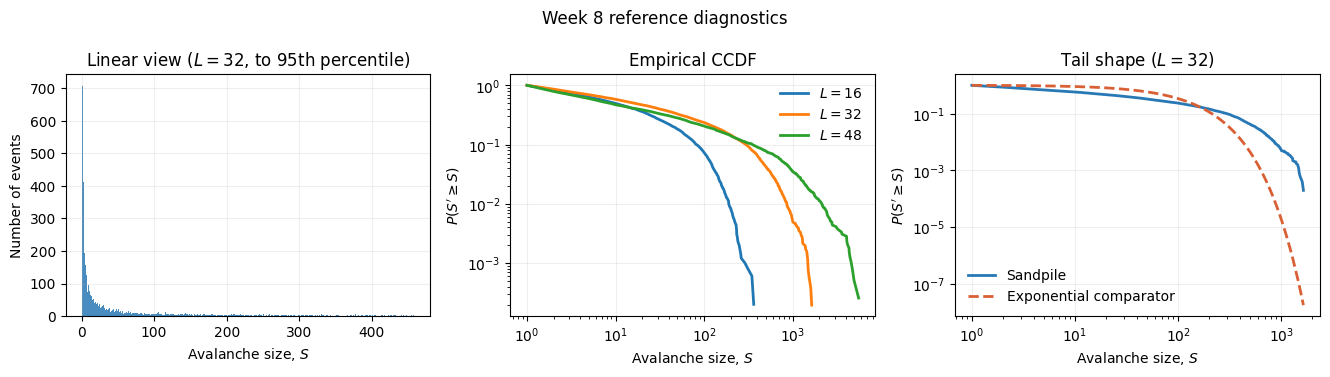

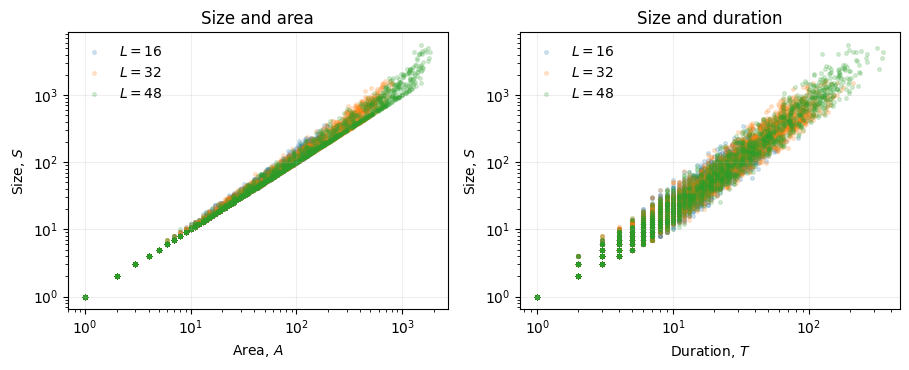

In [7]:
%run WS_Critical_phenomena_instructor_checks.py